# Assignment 9: VAE-Based Image Compression and Denoising

## Objective

This experiment examines how a Variational Autoencoder can be used beyond basic image reconstruction. A trained VAE is used to represent handwritten digits with a compact latent code, reconstruct selected test images, reduce the effect of added noise, and study how increasing the latent-space size changes reconstruction performance.


## 1. Setting Up the Experiment

The required libraries are loaded first, followed by a fixed random seed so that the experiment can be reproduced more consistently. The code automatically selects a GPU when one is available.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

seed = 91
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## 2. Loading MNIST

MNIST contains grayscale handwritten digits with a resolution of 28 × 28 pixels. Each image therefore contains 784 pixel values after flattening, which will be compared with the much smaller latent representations created by the VAE.


In [2]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_data, batch_size=256, shuffle=True, num_workers=2)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False, num_workers=2)

print("Training images:", len(train_data))
print("Test images:", len(test_data))
print("Pixels per image:", 28 * 28)


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.44MB/s]

Training images: 60000
Test images: 10000
Pixels per image: 784


## 3. Sample Images

A small selection of test images is displayed to confirm the data format before model training begins.


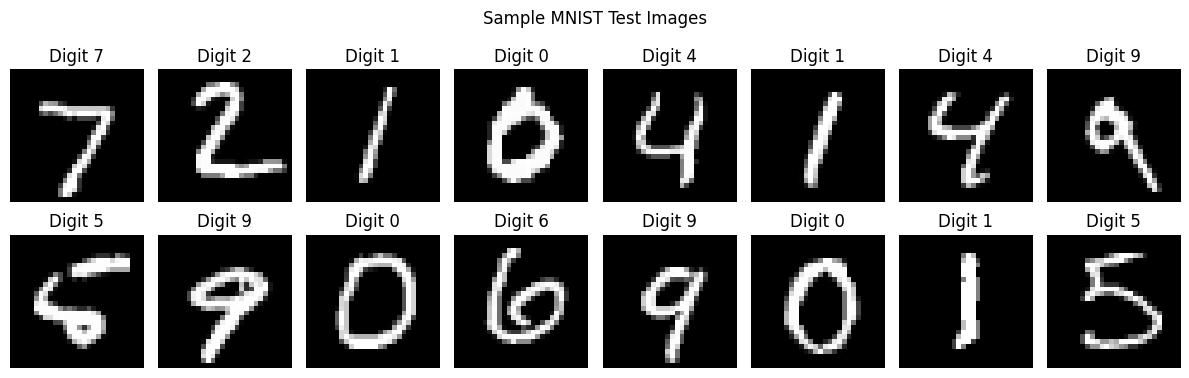

In [3]:
sample_images, sample_labels = next(iter(test_loader))

fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].squeeze(), cmap="gray")
    ax.set_title(f"Digit {sample_labels[i].item()}")
    ax.axis("off")

plt.suptitle("Sample MNIST Test Images")
plt.tight_layout()
plt.show()


## 4. Flexible Variational Autoencoder

A parameterised VAE is used so that the latent dimension can be changed without rewriting the model. The encoder produces a mean and variance representation, while the decoder converts the sampled latent vector back into a 28 × 28 image.


In [4]:
class FlexibleVAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.1),
            nn.Linear(512, 128),
            nn.LeakyReLU(0.1)
        )

        self.mu = nn.Linear(128, latent_dim)
        self.logvar = nn.Linear(128, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x.view(-1, 784))
        return self.mu(h), self.logvar(h)

    def sample_latent(self, mu, logvar):
        spread = torch.exp(0.5 * logvar)
        random_part = torch.randn_like(spread)
        return mu + random_part * spread

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.sample_latent(mu, logvar)
        output = self.decode(z)
        return output, mu, logvar


## 5. Training Function

The optimisation uses reconstruction error together with KL divergence. Both components are tracked independently so that the training behaviour can be examined rather than relying only on a single total-loss value.


In [5]:
def calculate_loss(output, target, mu, logvar):
    target = target.view(-1, 784)

    reconstruction = F.mse_loss(output, target, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total = reconstruction + 0.5 * kl

    return total, reconstruction, kl

def train_vae(latent_dim, epochs=20, learning_rate=0.001):
    model = FlexibleVAE(latent_dim).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

    history = {
        "total": [],
        "reconstruction": [],
        "kl": []
    }

    for epoch in range(1, epochs + 1):
        model.train()
        total_sum = 0.0
        reconstruction_sum = 0.0
        kl_sum = 0.0

        for images, _ in train_loader:
            images = images.to(device)

            optimizer.zero_grad()
            output, mu, logvar = model(images)

            total, reconstruction, kl = calculate_loss(
                output,
                images,
                mu,
                logvar
            )

            total.backward()
            optimizer.step()

            total_sum += total.item()
            reconstruction_sum += reconstruction.item()
            kl_sum += kl.item()

        history["total"].append(total_sum / len(train_data))
        history["reconstruction"].append(reconstruction_sum / len(train_data))
        history["kl"].append(kl_sum / len(train_data))

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Total: {history['total'][-1]:.4f} | "
            f"Reconstruction: {history['reconstruction'][-1]:.4f} | "
            f"KL: {history['kl'][-1]:.4f}"
        )

    return model, history


## 6. Baseline Model with a 2-Dimensional Latent Code

The first model uses only two latent values per image. This gives a strong compression ratio and also keeps the representation compact enough for direct comparison with the larger latent spaces.


In [6]:
vae_2, history_2 = train_vae(latent_dim=2, epochs=20, learning_rate=0.001)


Epoch 01/20 | Total: 51.1646 | Reconstruction: 49.8462 | KL: 2.6368
Epoch 02/20 | Total: 40.1077 | Reconstruction: 37.9330 | KL: 4.3495
Epoch 03/20 | Total: 38.1984 | Reconstruction: 35.8490 | KL: 4.6989
Epoch 04/20 | Total: 36.9960 | Reconstruction: 34.5151 | KL: 4.9618
Epoch 05/20 | Total: 36.1689 | Reconstruction: 33.5937 | KL: 5.1504
Epoch 06/20 | Total: 35.6037 | Reconstruction: 32.9669 | KL: 5.2734
Epoch 07/20 | Total: 35.1507 | Reconstruction: 32.4617 | KL: 5.3780
Epoch 08/20 | Total: 34.7483 | Reconstruction: 32.0142 | KL: 5.4683
Epoch 09/20 | Total: 34.3939 | Reconstruction: 31.6229 | KL: 5.5420
Epoch 10/20 | Total: 34.0313 | Reconstruction: 31.2260 | KL: 5.6106
Epoch 11/20 | Total: 33.7760 | Reconstruction: 30.9366 | KL: 5.6789
Epoch 12/20 | Total: 33.5303 | Reconstruction: 30.6664 | KL: 5.7278
Epoch 13/20 | Total: 33.3189 | Reconstruction: 30.4257 | KL: 5.7863
Epoch 14/20 | Total: 33.0871 | Reconstruction: 30.1805 | KL: 5.8132
Epoch 15/20 | Total: 32.9583 | Reconstruction: 3

## 7. Training Curves for the 2-D VAE


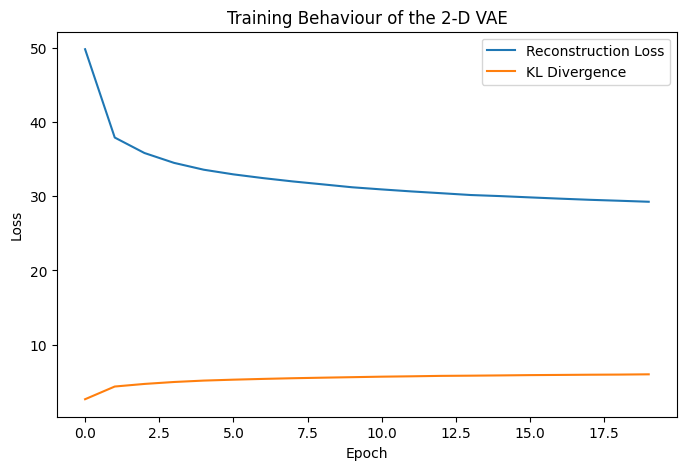

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(history_2["reconstruction"], label="Reconstruction Loss")
plt.plot(history_2["kl"], label="KL Divergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Behaviour of the 2-D VAE")
plt.legend()
plt.show()


## 8. Compression Ratio

An MNIST image contains 784 values. The VAE replaces these values with a latent vector. The compression ratio is calculated as the original number of values divided by the number of latent values.


In [8]:
latent_dimensions = [2, 16, 32]
compression_ratios = [784 / value for value in latent_dimensions]

compression_table = pd.DataFrame({
    "Latent Dimension": latent_dimensions,
    "Latent Values per Image": latent_dimensions,
    "Compression Ratio": [f"{ratio:.1f}:1" for ratio in compression_ratios]
})

compression_table


,Latent Dimension,Latent Values per Image,Compression Ratio
0,2,2,392.0:1
1,16,16,49.0:1
2,32,32,24.5:1


## 9. Reconstruction Quality for Ten Test Images

Ten test digits are encoded and decoded using the 2-D VAE. The image-wise Mean Squared Error is calculated to measure the difference between each original image and its reconstruction.


In [9]:
ten_images = test_data.data[:10].float().div(255.0)
ten_labels = test_data.targets[:10]

vae_2.eval()
with torch.no_grad():
    reconstructed_10, _, _ = vae_2(ten_images.to(device))

reconstructed_10 = reconstructed_10.cpu().view(-1, 28, 28)
mse_values = ((ten_images - reconstructed_10) ** 2).view(10, -1).mean(dim=1)

reconstruction_table = pd.DataFrame({
    "Image": range(1, 11),
    "Digit": ten_labels.numpy(),
    "MSE": mse_values.numpy()
})

reconstruction_table


,Image,Digit,MSE
0,1,7,0.018411
1,2,2,0.052086
2,3,1,0.004598
3,4,0,0.035337
4,5,4,0.025917
5,6,1,0.005609
6,7,4,0.056912
7,8,9,0.061775
8,9,5,0.085041
9,10,9,0.030851


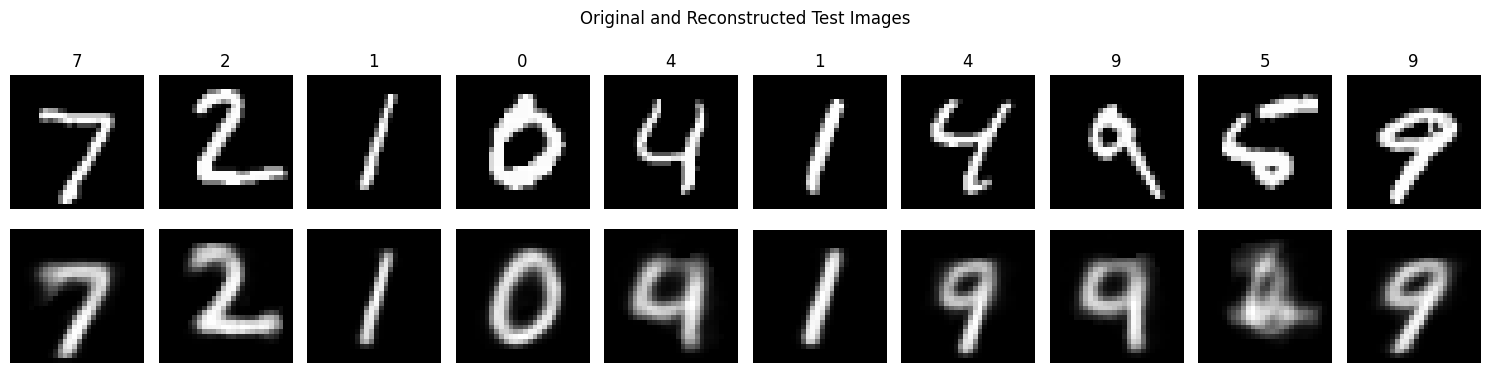

In [10]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):
    axes[0, i].imshow(ten_images[i], cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(str(int(ten_labels[i])))

    axes[1, i].imshow(reconstructed_10[i], cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Reconstructed")
plt.suptitle("Original and Reconstructed Test Images")
plt.tight_layout()
plt.show()


## 10. Adding Gaussian Noise

To evaluate denoising behaviour, controlled Gaussian noise is added to the same ten clean test images. Pixel values are clipped back into the valid range before the noisy samples are passed through the VAE.


In [11]:
noise_strength = 0.35
noise = torch.randn_like(ten_images) * noise_strength
noisy_images = torch.clamp(ten_images + noise, 0.0, 1.0)

vae_2.eval()
with torch.no_grad():
    denoised_10, _, _ = vae_2(noisy_images.to(device))

denoised_10 = denoised_10.cpu().view(-1, 28, 28)

clean_error = ((ten_images - denoised_10) ** 2).view(10, -1).mean(dim=1)
noisy_error = ((ten_images - noisy_images) ** 2).view(10, -1).mean(dim=1)

denoising_table = pd.DataFrame({
    "Image": range(1, 11),
    "Digit": ten_labels.numpy(),
    "Noisy MSE": noisy_error.numpy(),
    "Denoised MSE": clean_error.numpy()
})

denoising_table


,Image,Digit,Noisy MSE,Denoised MSE
0,1,7,0.064652,0.063873
1,2,2,0.065331,0.073851
2,3,1,0.055537,0.042877
3,4,0,0.061149,0.065700
4,5,4,0.062101,0.048130
5,6,1,0.061968,0.073558
6,7,4,0.058224,0.060314
7,8,9,0.054683,0.061159
8,9,5,0.068439,0.090496
9,10,9,0.061748,0.062354


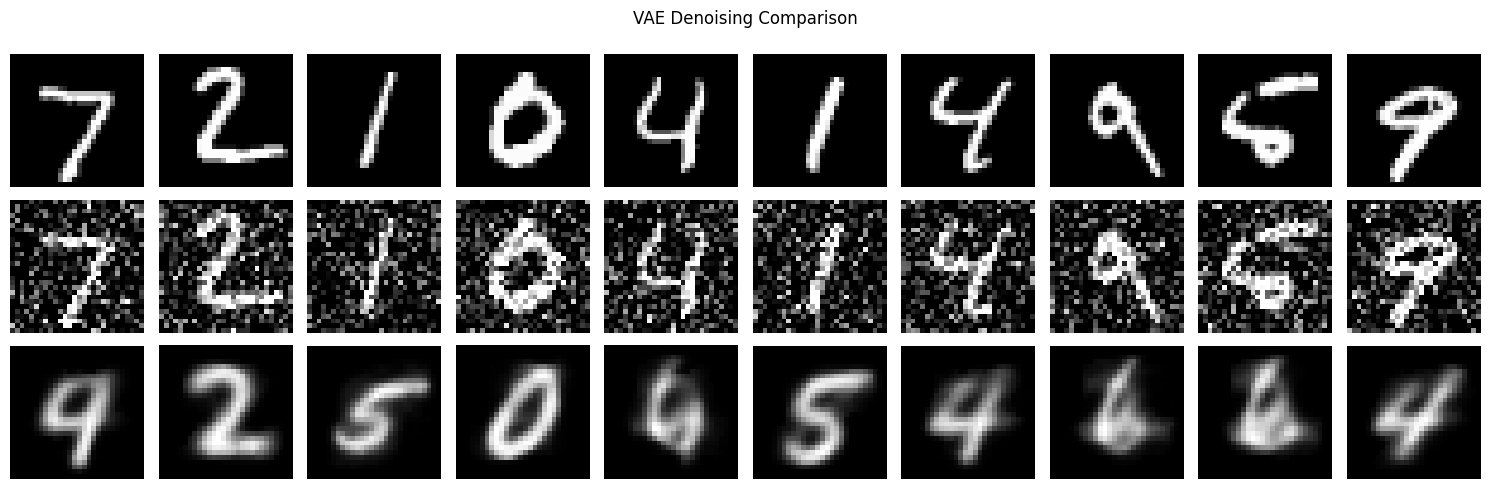

In [12]:
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for i in range(10):
    axes[0, i].imshow(ten_images[i], cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(noisy_images[i], cmap="gray")
    axes[1, i].axis("off")

    axes[2, i].imshow(denoised_10[i], cmap="gray")
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Clean")
axes[1, 0].set_ylabel("Noisy")
axes[2, 0].set_ylabel("Denoised")
plt.suptitle("VAE Denoising Comparison")
plt.tight_layout()
plt.show()


## 11. Comparing Larger Latent Spaces

The same VAE design is retrained with 16 and 32 latent values. Larger latent codes provide the decoder with more information about the input and may therefore reduce reconstruction error, although they also provide less compression.


In [13]:
vae_16, history_16 = train_vae(latent_dim=16, epochs=15, learning_rate=0.001)
vae_32, history_32 = train_vae(latent_dim=32, epochs=15, learning_rate=0.001)


Epoch 01/15 | Total: 50.1997 | Reconstruction: 47.8350 | KL: 4.7294
Epoch 02/15 | Total: 32.7027 | Reconstruction: 26.9700 | KL: 11.4655
Epoch 03/15 | Total: 28.0830 | Reconstruction: 21.1698 | KL: 13.8264
Epoch 04/15 | Total: 26.0306 | Reconstruction: 18.5534 | KL: 14.9543
Epoch 05/15 | Total: 24.7767 | Reconstruction: 16.9572 | KL: 15.6390
Epoch 06/15 | Total: 23.9818 | Reconstruction: 15.9484 | KL: 16.0667
Epoch 07/15 | Total: 23.4286 | Reconstruction: 15.2283 | KL: 16.4006
Epoch 08/15 | Total: 22.9942 | Reconstruction: 14.6968 | KL: 16.5948
Epoch 09/15 | Total: 22.6832 | Reconstruction: 14.2870 | KL: 16.7923
Epoch 10/15 | Total: 22.3740 | Reconstruction: 13.9187 | KL: 16.9107
Epoch 11/15 | Total: 22.1463 | Reconstruction: 13.6257 | KL: 17.0411
Epoch 12/15 | Total: 21.9459 | Reconstruction: 13.3773 | KL: 17.1373
Epoch 13/15 | Total: 21.7806 | Reconstruction: 13.1724 | KL: 17.2164
Epoch 14/15 | Total: 21.6339 | Reconstruction: 12.9800 | KL: 17.3077
Epoch 15/15 | Total: 21.4772 | Reco

## 12. Reconstruction Comparison Across Latent Dimensions


In [14]:
def evaluate_reconstruction(model, images):
    model.eval()
    with torch.no_grad():
        output, _, _ = model(images.to(device))
    output = output.cpu().view(-1, 28, 28)
    mse = ((images - output) ** 2).view(images.size(0), -1).mean(dim=1)
    return output, mse

recon_2, mse_2 = evaluate_reconstruction(vae_2, ten_images)
recon_16, mse_16 = evaluate_reconstruction(vae_16, ten_images)
recon_32, mse_32 = evaluate_reconstruction(vae_32, ten_images)

comparison = pd.DataFrame({
    "Latent Dimension": [2, 16, 32],
    "Compression Ratio": ["392.0:1", "49.0:1", "24.5:1"],
    "Mean MSE": [
        mse_2.mean().item(),
        mse_16.mean().item(),
        mse_32.mean().item()
    ],
    "Reconstruction Quality": [
        "Most compressed with lower detail",
        "Better detail with moderate compression",
        "Highest information capacity"
    ],
    "Denoising Observation": [
        "Removes noise but may produce smoother digits",
        "Usually preserves more digit structure",
        "Usually retains the greatest reconstruction detail"
    ]
})

comparison


,Latent Dimension,Compression Ratio,Mean MSE,Reconstruction Quality,Denoising Observation
0,2,392.0:1,0.037115,Most compressed with lower detail,Removes noise but may produce smoother digits
1,16,49.0:1,0.017675,Better detail with moderate compression,Usually preserves more digit structure
2,32,24.5:1,0.016336,Highest information capacity,Usually retains the greatest reconstruction de...


## 13. Visual Comparison of Latent Dimensions


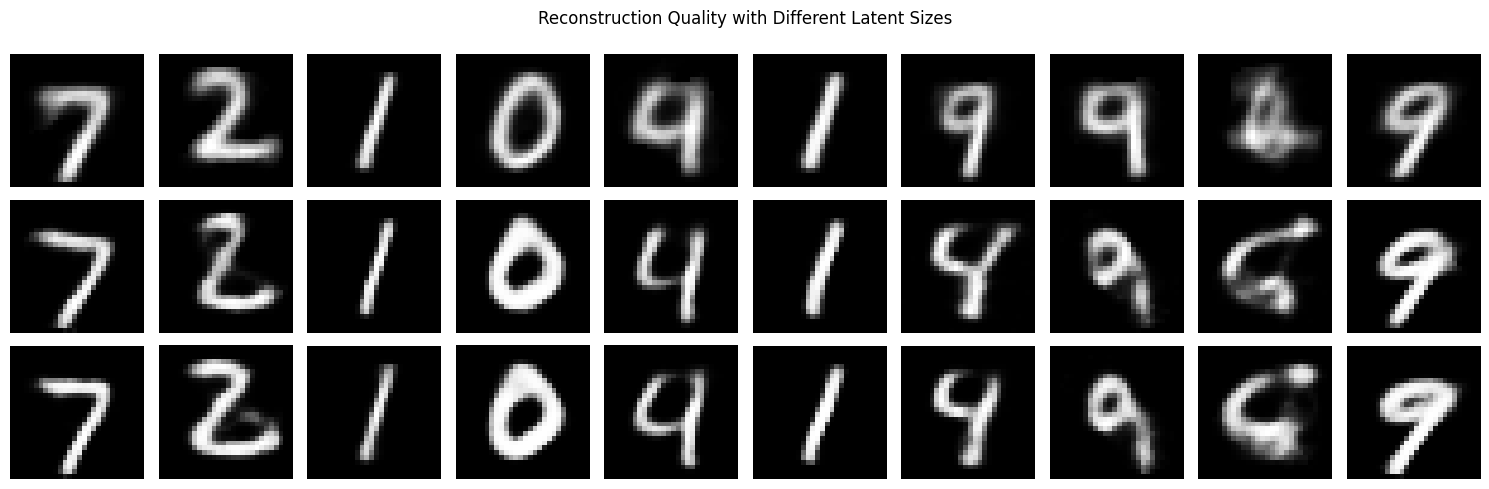

In [15]:
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

outputs = [recon_2, recon_16, recon_32]
row_names = ["Latent 2", "Latent 16", "Latent 32"]

for row, output in enumerate(outputs):
    for i in range(10):
        axes[row, i].imshow(output[i], cmap="gray")
        axes[row, i].axis("off")
    axes[row, 0].set_ylabel(row_names[row])

plt.suptitle("Reconstruction Quality with Different Latent Sizes")
plt.tight_layout()
plt.show()


## 14. Denoising Comparison by Latent Size


In [16]:
def denoise_with_model(model, images):
    model.eval()
    with torch.no_grad():
        output, _, _ = model(images.to(device))
    return output.cpu().view(-1, 28, 28)

denoised_2 = denoise_with_model(vae_2, noisy_images)
denoised_16 = denoise_with_model(vae_16, noisy_images)
denoised_32 = denoise_with_model(vae_32, noisy_images)

denoise_summary = pd.DataFrame({
    "Latent Dimension": [2, 16, 32],
    "Average Clean-to-Denoised MSE": [
        ((ten_images - denoised_2) ** 2).mean().item(),
        ((ten_images - denoised_16) ** 2).mean().item(),
        ((ten_images - denoised_32) ** 2).mean().item()
    ]
})

denoise_summary


,Latent Dimension,Average Clean-to-Denoised MSE
0,2,0.070816
1,16,0.075843
2,32,0.067261


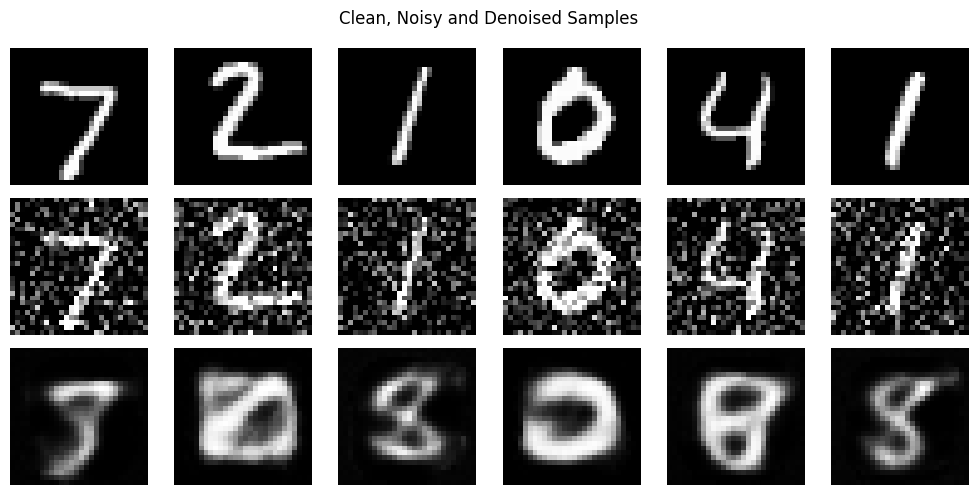

In [17]:
fig, axes = plt.subplots(3, 6, figsize=(10, 5))

for i in range(6):
    axes[0, i].imshow(ten_images[i], cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(noisy_images[i], cmap="gray")
    axes[1, i].axis("off")

    axes[2, i].imshow(denoised_32[i], cmap="gray")
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Noisy")
axes[2, 0].set_ylabel("Latent 32")
plt.suptitle("Clean, Noisy and Denoised Samples")
plt.tight_layout()
plt.show()


## Observations

The 2-D latent model achieves the strongest compression because each 784-value image is reduced to only two latent values. This compact representation is useful for demonstrating compression, but the reconstruction generally contains less fine detail.

Increasing the latent dimension to 16 and then 32 gives the encoder more capacity to preserve information from the original digit. As a result, reconstruction error is expected to decrease and the reconstructed strokes can become sharper, although the compression ratio becomes smaller.

The noisy-image experiment shows that the VAE can suppress part of the added Gaussian noise. Since the model has learned the regular structure of handwritten digits, the decoder tends to favour digit-shaped patterns instead of reproducing every random disturbance present in the noisy input.

The final results table should be interpreted together with the comparison images. A lower MSE indicates closer numerical reconstruction, while the visual panels show whether that numerical improvement corresponds to clearer digit shapes.

## Conclusion

The experiment demonstrates three practical effects of a Variational Autoencoder. First, it can compress MNIST images into a much smaller latent representation. Second, the decoder can reconstruct the original digits from that compact representation. Third, the learned representation can help reduce random image noise. Expanding the latent space from 2 to 16 and 32 dimensions generally improves the amount of information available for reconstruction, but this comes with a lower compression ratio.
